# DSI Übungsprojekt Olympia

Dieses Projekt analysiert olympische Athletendaten mit dem Ziel, datenbasierte Erkenntnisse für verschiedene Zielgruppen – darunter Trainer, Sportverbände und Athleten – zu gewinnen. Untersucht werden Zusammenhänge zwischen körperlichen Merkmalen, Herkunft, Erfahrung und Medaillenerfolg anhand historischer Olympiadaten.

---

# Fragestellung 1: Körperliches Profil & Medaillenerfolg

**Zielgruppe:** Trainer

---

## Fragestellung

Gibt es einen Zusammenhang zwischen den **körperlichen Merkmalen** eines Athleten – Größe, Gewicht und BMI – und dem **Medaillenerfolg**? Unterscheiden sich mögliche Muster je nach **Sportart** oder **Geschlecht**?

---

## Relevanz für Trainer

> Durch die Analyse der Zusammenhänge zwischen körperlichem Profil und Wettkampfergebnissen lassen sich Trainings- und Wettkampfergebnisse besser **benchmarken**.

Trainer erhalten damit eine datenbasierte Grundlage, um:
- Athletenprofile gezielt einzuordnen
- Leistungserwartungen realistisch zu kalibrieren
- Sportartspezifische Körperideale zu identifizieren

---

## Untersuchte Merkmale

| Merkmal | Beschreibung |
|--------|-------------|
| **Größe** | Körpergröße des Athleten in cm |
| **Gewicht** | Körpergewicht in kg |
| **BMI** | Body-Mass-Index (kg/m²) |

---

## Analyseebenen

1. **Gesamtbetrachtung** – Zusammenhang zwischen körperlichen Merkmalen und Medaillengewinn allgemein
2. **Nach Sportart** – Unterschiede im körperlichen Profil erfolgreicher Athleten je Disziplin
3. **Nach Geschlecht** – Vergleich der Muster zwischen männlichen und weiblichen Athleten

---

## Erwarteter Erkenntnisgewinn

Durch diese Analyse können Trainer:

- **Benchmarks** für körperliche Profile in ihrer Sportart ableiten
- Einschätzen, ob ein Athlet im **optimalen Leistungsbereich** liegt
- Gezielte Empfehlungen für **Gewichts- oder Konditionsanpassungen** entwickeln

## Setup & Datenimport

Zunächst werden alle benötigten Bibliotheken geladen – darunter **Pandas** für die Datenverarbeitung sowie **Matplotlib** und **Seaborn** für die Visualisierung. Anschließend wird der olympische Datensatz als CSV-Datei eingelesen und eine erste Übersicht der Daten ausgegeben.

In [2]:
#libraries importieren
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../olympics.csv', sep=';')
df.head()

,ID,Name,Sex,Age,Height,Weight,Year,Sport,Event,Medal,NOC,Country
0,1,A Dijiang,M,24,1800.0,800.0,1992,Basketball,Basketball Men's Basketball,NaN,CHN,China
1,2,A Lamusi,M,23,1700.0,600.0,2012,Judo,Judo Men's Extra-Lightweight,NaN,CHN,China
2,3,Gunnar Nielsen Aaby,M,24,NaN,NaN,1920,Football,Football Men's Football,NaN,DEN,Denmark
3,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18,1680.0,NaN,1932,Athletics,Athletics Women's 100 metres,NaN,NED,Netherlands
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18,1680.0,NaN,1932,Athletics,Athletics Women's 4 x 100 metres Relay,NaN,NED,Netherlands


## Datenbereinigung

Bevor die Analyse beginnt, wird der Datensatz bereinigt. Athleten ohne Angaben zu **Größe**, **Gewicht** oder **Herkunftsland** werden entfernt. Das **Alter** wird auf mindestens 11 Jahre gefiltert – basierend auf dem jüngsten bestätigten Olympiateilnehmer im Datensatz. Fehlende **Medaillenwerte** werden als `None` gekennzeichnet. Abschließend werden **Größe** (in Meter) und **Gewicht** (in kg) in die korrekten

In [3]:
#Athleten ohne Größe, Gewicht und Country löschen
df = df.dropna(subset=['Height', 'Weight'])
df = df.dropna(subset=['Country'])

#Alter bereinigen, Der jüngste bestätigte Olympiateilnehmer im Datensatz war Liana Vicens (1968, 11 Jahre)
df = df[df['Age'] >= 11]

#Fehlende Werte für Medaillen als 'Keine Medaille' kennzeichnen
df['Medal'] = df['Medal'].fillna('Keine Medaille')

#Height im Meter transformieren
df['Height'] = df['Height'] / 1000

#Weight in kg transformieren
df['Weight'] = df['Weight'] / 10

## Deskriptive Statistik

Ein erster Überblick über die **Verteilung und Kennzahlen** des bereinigten Datensatzes – darunter Mittelwert, Standardabweichung sowie Minimum und Maximum aller numerischen Spalten.

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 166110 entries, 0 to 216783
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   ID       166110 non-null  int64  
 1   Name     166110 non-null  object 
 2   Sex      166110 non-null  object 
 3   Age      166110 non-null  int64  
 4   Height   166110 non-null  float64
 5   Weight   166110 non-null  float64
 6   Year     166110 non-null  int64  
 7   Sport    166110 non-null  object 
 8   Event    166110 non-null  object 
 9   Medal    166110 non-null  object 
 10  NOC      166110 non-null  object 
 11  Country  166110 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 16.5+ MB
None


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)
print(df.describe())

             ID       Age    Height    Weight      Year
count 166110.00 166110.00 166110.00 166110.00 166110.00
mean   68258.67     25.05      1.76     70.67   1988.76
std    39126.82      5.66      0.11     14.81     20.48
min        1.00     11.00      1.27     25.00   1904.00
25%    34404.00     21.00      1.68     60.00   1972.00
50%    68669.00     24.00      1.75     70.00   1992.00
75%   101960.00     28.00      1.83     79.00   2004.00
max   135568.00     71.00      2.26    214.00   2016.00


## Primärschlüssel

Da der Datensatz keinen eindeutigen Identifier enthält, wird ein künstlicher **Primärschlüssel** generiert und als erste Spalte eingefügt.

In [6]:
#Primärschlüssel bilden
df['PK'] = range(100001, 100001 + len(df))
#Primärschlüssel nach vorne ziehen
cols = ['PK'] + [col for col in df.columns if col != 'PK']
df = df[cols]

## Finale Prüfung

Abschließende Sichtprüfung des bereinigten und transformierten Datensatzes.

In [7]:
#daten anzeigen zur finalen prüfung
df.head()

,PK,ID,Name,Sex,Age,Height,Weight,Year,Sport,Event,Medal,NOC,Country
0,100001,1,A Dijiang,M,24,1.80,80.00,1992,Basketball,Basketball Men's Basketball,Keine Medaille,CHN,China
1,100002,2,A Lamusi,M,23,1.70,60.00,2012,Judo,Judo Men's Extra-Lightweight,Keine Medaille,CHN,China
6,100003,12,Jyri Tapani Aalto,M,31,1.72,70.00,2000,Badminton,Badminton Men's Singles,Keine Medaille,FIN,Finland
7,100004,13,Minna Maarit Aalto,F,30,1.59,55.50,1996,Sailing,Sailing Women's Windsurfer,Keine Medaille,FIN,Finland
8,100005,13,Minna Maarit Aalto,F,34,1.59,55.50,2000,Sailing,Sailing Women's Windsurfer,Keine Medaille,FIN,Finland


## Datenexport

Der bereinigte Datensatz wird in ein **relationales Datenbankschema** überführt und für den Import in PostgreSQL vorbereitet. Dazu wird der Datensatz in vier Tabellen aufgeteilt:

- **Athletes** – eindeutige Athletenprofile (ID, Name, Geschlecht)
- **Countries** – Länderzuordnung über den NOC-Code
- **Events** – Sportarten und Disziplinen mit generiertem Primärschlüssel
- **Athlete_Event** – Faktentabelle mit allen Wettkampfteilnahmen inkl. Medaille, Alter, Größe und Gewicht

Jede Tabelle wird als separate CSV-Datei exportiert.

In [8]:
#Daten exportieren zur Weiterverarbeitung in PostgreSQL

# Athletes
athletes = df[['ID', 'Name', 'Sex']].drop_duplicates(subset='ID').rename(columns={'ID': 'athlete_id'})

# Countries
countries = df[['NOC', 'Country']].drop_duplicates().rename(columns={'NOC': 'noc', 'Country': 'country'})

# Events
df['event_id'] = df.groupby(['Sport', 'Event']).ngroup() + 1
events = df[['event_id', 'Sport', 'Event']].drop_duplicates().rename(columns={'Sport': 'sport', 'Event': 'event'})

# Athlete_Event (Faktentabelle)
athlete_event = df[['ID', 'event_id', 'Year', 'Medal', 'Age', 'Height', 'Weight', 'NOC']].rename(columns={
    'ID': 'athlete_id',
    'Year': 'year',
    'Medal': 'medal',
    'Age': 'age',
    'Height': 'height',
    'Weight': 'weight',
    'NOC': 'noc'
})

# Export
athletes.to_csv('../data/athletes.csv', index=False)
countries.to_csv('../data/countries.csv', index=False)
events.to_csv('../data/events.csv', index=False)
athlete_event.to_csv('../data/athlete_event.csv', index=False)

## Datenbankanbindung & Datenimport

Die exportierten Tabellen wurden in **PostgreSQL** importiert. Für die Analyse wird der Datensatz über einen SQL-Join aus den Tabellen `athlete_event`, `athletes` und `events` zusammengeführt und direkt in einen Pandas DataFrame geladen.

In [9]:

from sqlalchemy import create_engine
from dotenv import load_dotenv
import pandas as pd
import os

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("""
    SELECT a.athlete_id, a.sex, ae.age, ae.height, ae.weight, ae.medal, ae.year, ae.noc, e.sport, e.event
    FROM athlete_event ae
    JOIN athletes a ON ae.athlete_id = a.athlete_id
    JOIN events e ON ae.event_id = e.event_id
""", engine)

df.head()

,athlete_id,sex,age,height,weight,medal,year,noc,sport,event
0,1,M,24,1.80,80.00,None,1992,CHN,Basketball,Basketball Men's Basketball
1,2,M,23,1.70,60.00,None,2012,CHN,Judo,Judo Men's Extra-Lightweight
2,12,M,31,1.72,70.00,None,2000,FIN,Badminton,Badminton Men's Singles
3,13,F,30,1.59,55.50,None,1996,FIN,Sailing,Sailing Women's Windsurfer
4,13,F,34,1.59,55.50,None,2000,FIN,Sailing,Sailing Women's Windsurfer


## Feature Engineering

Für die Analyse werden zwei neue Merkmale berechnet: Der **BMI** wird aus Gewicht und Größe abgeleitet. Zusätzlich wird eine binäre Variable **hat_medaille** erstellt, die zwischen Medaillengewinnern und Nicht-Gewinnern unterscheidet.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# BMI berechnen
df['bmi'] = df['weight'] / (df['height'] ** 2)

# Medaille ja/nein
df['hat_medaille'] = df['medal'].isin(['Gold', 'Silver', 'Bronze']).map(
    {True: 'Medaille', False: 'Keine Medaille'}
)

df.head()

,athlete_id,sex,age,height,weight,medal,year,noc,sport,event,bmi,hat_medaille
0,1,M,24,1.80,80.00,None,1992,CHN,Basketball,Basketball Men's Basketball,24.69,Keine Medaille
1,2,M,23,1.70,60.00,None,2012,CHN,Judo,Judo Men's Extra-Lightweight,20.76,Keine Medaille
2,12,M,31,1.72,70.00,None,2000,FIN,Badminton,Badminton Men's Singles,23.66,Keine Medaille
3,13,F,30,1.59,55.50,None,1996,FIN,Sailing,Sailing Women's Windsurfer,21.95,Keine Medaille
4,13,F,34,1.59,55.50,None,2000,FIN,Sailing,Sailing Women's Windsurfer,21.95,Keine Medaille


## Analyse: Alter & Medaillenerfolg

Um zu untersuchen, ob das Alter einen Einfluss auf den Medaillenerfolg hat, wird der **mediane Altersunterschied** zwischen Gewinnern und Nicht-Gewinnern je Sportart berechnet. Die 15 Sportarten mit der größten absoluten Altersdifferenz werden visualisiert und in zwei Gruppen unterteilt: Sportarten, in denen Gewinner **älter** sind, und solche, in denen Gewinner **jünger** sind.

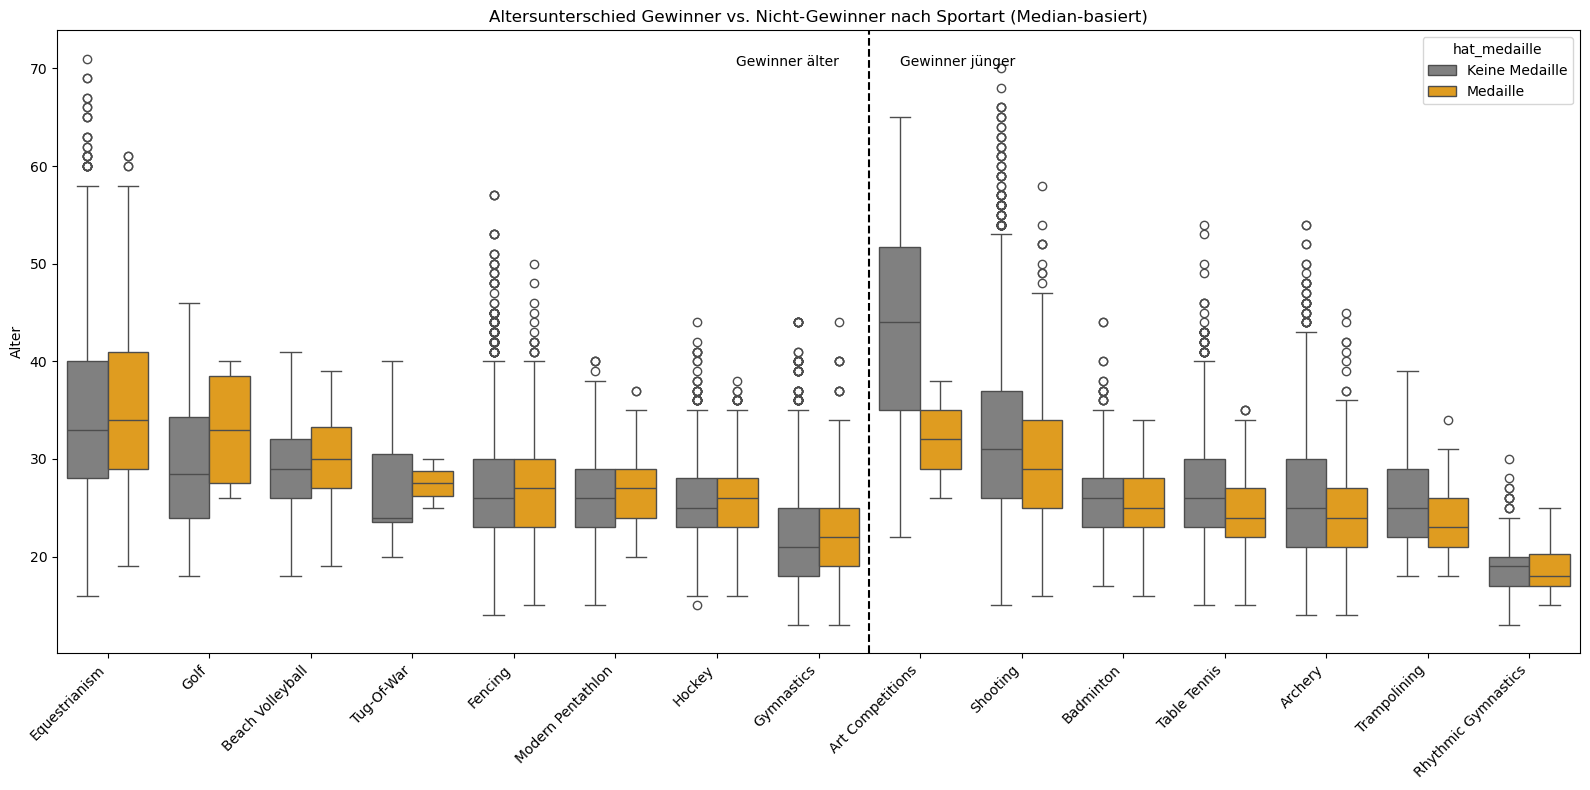

In [11]:
# Median-basierte Altersanalyse
age_diff = df.groupby(['sport', 'hat_medaille'])['age'].median().unstack()
age_diff.columns.name = None
age_diff['differenz'] = age_diff['Medaille'] - age_diff['Keine Medaille']
age_diff = age_diff.dropna()
age_diff['abs_differenz'] = age_diff['differenz'].abs()
age_diff = age_diff[age_diff['abs_differenz'] > 0]
age_diff['gruppe'] = age_diff['differenz'].apply(lambda x: 'Gewinner älter' if x > 0 else 'Gewinner jünger')
age_diff = age_diff.nlargest(15, 'abs_differenz')
age_diff = age_diff.sort_values(['gruppe', 'Medaille'], ascending=[False, False])

top_sports_age = age_diff.index
df_age_top = df[df['sport'].isin(top_sports_age)].copy()
df_age_top = df_age_top.merge(age_diff[['gruppe']], on='sport')

n_older = (age_diff['gruppe'] == 'Gewinner älter').sum()

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_age_top, x='sport', y='age', hue='hat_medaille',
            order=top_sports_age,
            palette={'Medaille': 'orange', 'Keine Medaille': 'gray'})

plt.axvline(x=n_older - 0.5, color='black', linestyle='--', linewidth=1.5)
plt.text(n_older - 0.5 - 0.3, plt.ylim()[1] * 0.95, 'Gewinner älter', ha='right', fontsize=10)
plt.text(n_older - 0.5 + 0.3, plt.ylim()[1] * 0.95, 'Gewinner jünger', ha='left', fontsize=10)

plt.title('Altersunterschied Gewinner vs. Nicht-Gewinner nach Sportart (Median-basiert)')
plt.xlabel('')
plt.ylabel('Alter')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analyse: Größe & Medaillenerfolg

Analog zur Altersanalyse wird der **mediane Größenunterschied** zwischen Gewinnern und Nicht-Gewinnern je Sportart berechnet. Die 15 Sportarten mit der größten absoluten Differenz werden visualisiert und in zwei Gruppen unterteilt: Sportarten, in denen Gewinner **größer** sind, und solche, in denen Gewinner **kleiner** sind. Innerhalb jeder Gruppe sind die Sportarten nach dem **Median der Gewinn

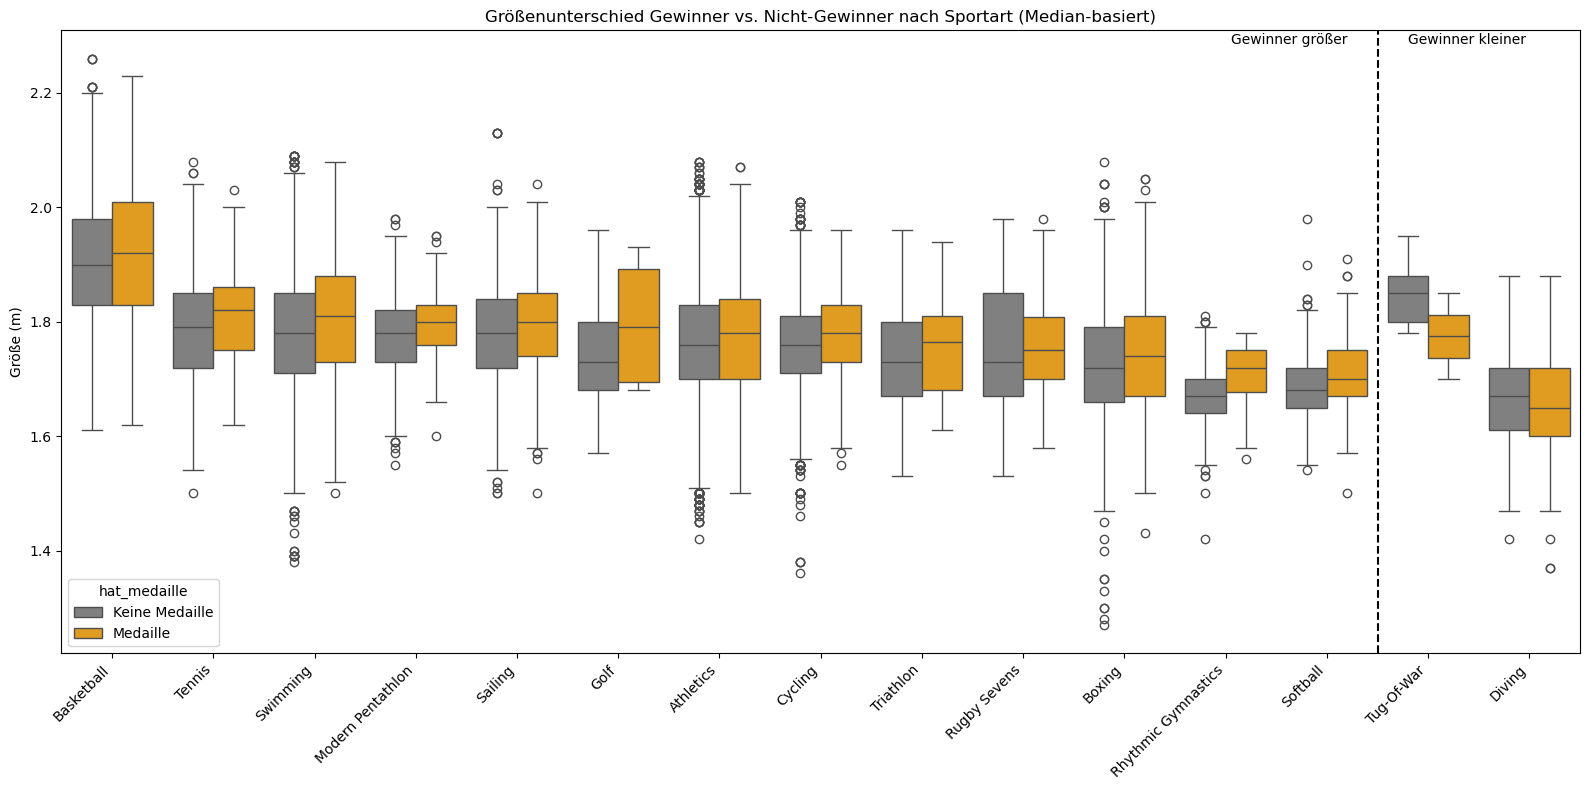

In [12]:
# Median-basierte Größen-Analyse
height_diff = df.groupby(['sport', 'hat_medaille'])['height'].median().unstack()
height_diff.columns.name = None
height_diff['differenz'] = height_diff['Medaille'] - height_diff['Keine Medaille']
height_diff = height_diff.dropna()
height_diff['abs_differenz'] = height_diff['differenz'].abs()
height_diff = height_diff[height_diff['abs_differenz'] > 0]
height_diff['gruppe'] = height_diff['differenz'].apply(lambda x: 'Gewinner größer' if x > 0 else 'Gewinner kleiner')
height_diff = height_diff.nlargest(15, 'abs_differenz')

# Sortierung nach Median der Gewinner absteigend
groesser = height_diff[height_diff['gruppe'] == 'Gewinner größer'].sort_values('Medaille', ascending=False)
kleiner = height_diff[height_diff['gruppe'] == 'Gewinner kleiner'].sort_values('Medaille', ascending=False)
height_diff_sorted = pd.concat([groesser, kleiner])

top_sports_height = list(height_diff_sorted.index)
df_height_top = df[df['sport'].isin(top_sports_height)].copy()
df_height_top = df_height_top.merge(height_diff_sorted[['gruppe']], on='sport')
n_groesser = len(groesser)

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_height_top, x='sport', y='height', hue='hat_medaille',
            order=top_sports_height,
            palette={'Medaille': 'orange', 'Keine Medaille': 'gray'})
plt.axvline(x=n_groesser - 0.5, color='black', linestyle='--', linewidth=1.5)
plt.text(n_groesser - 0.5 - 0.3, plt.ylim()[1] * 0.99, 'Gewinner größer', ha='right', fontsize=10)
plt.text(n_groesser - 0.5 + 0.3, plt.ylim()[1] * 0.99, 'Gewinner kleiner', ha='left', fontsize=10)
plt.title('Größenunterschied Gewinner vs. Nicht-Gewinner nach Sportart (Median-basiert)')
plt.xlabel('')
plt.ylabel('Größe (m)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Analyse: BMI & Medaillenerfolg

Abschließend wird der **mediane BMI-Unterschied** zwischen Gewinnern und Nicht-Gewinnern je Sportart untersucht. Die 15 Sportarten mit der größten absoluten Differenz werden in zwei Gruppen aufgeteilt: Sportarten, in denen Gewinner einen **höheren BMI** aufweisen, und solche, in denen Gewinner einen **niedrigeren BMI** haben.

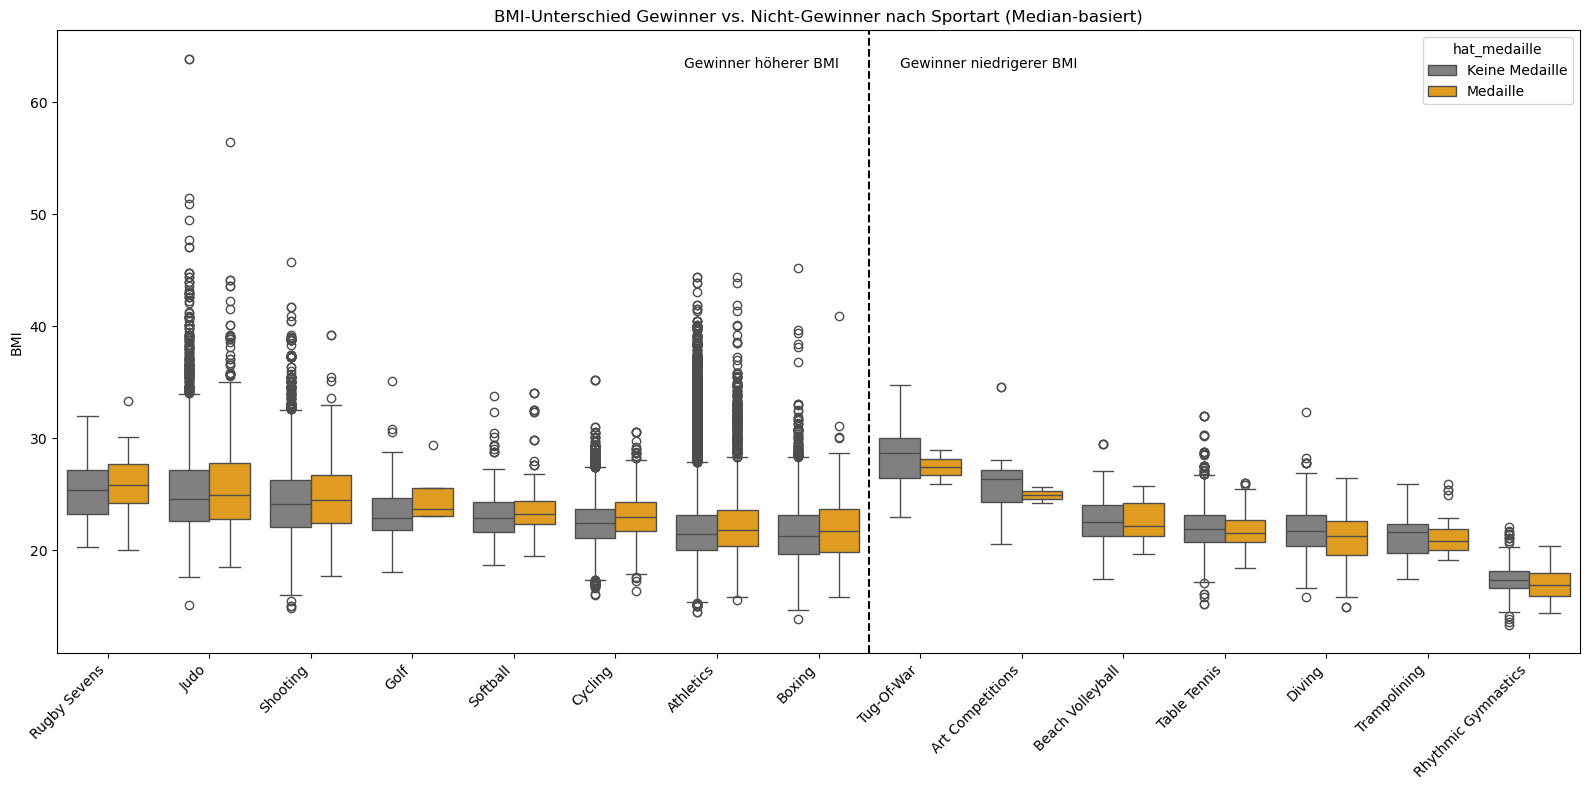

In [13]:
# Median-basierte BMI-Analyse
bmi_diff = df.groupby(['sport', 'hat_medaille'])['bmi'].median().unstack()
bmi_diff.columns.name = None
bmi_diff['differenz'] = bmi_diff['Medaille'] - bmi_diff['Keine Medaille']
bmi_diff = bmi_diff.dropna()
bmi_diff['abs_differenz'] = bmi_diff['differenz'].abs()
bmi_diff = bmi_diff[bmi_diff['abs_differenz'] > 0]
bmi_diff['gruppe'] = bmi_diff['differenz'].apply(lambda x: 'Gewinner höherer BMI' if x > 0 else 'Gewinner niedrigerer BMI')
bmi_diff = bmi_diff.nlargest(15, 'abs_differenz')
bmi_diff = bmi_diff.sort_values(['gruppe', 'Medaille'], ascending=[True, False])

top_sports_bmi = bmi_diff.index
df_bmi_top = df[df['sport'].isin(top_sports_bmi)].copy()
df_bmi_top = df_bmi_top.merge(bmi_diff[['gruppe']], on='sport')

n_higher = (bmi_diff['gruppe'] == 'Gewinner höherer BMI').sum()

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_bmi_top, x='sport', y='bmi', hue='hat_medaille',
            order=top_sports_bmi,
            palette={'Medaille': 'orange', 'Keine Medaille': 'gray'})

plt.axvline(x=n_higher - 0.5, color='black', linestyle='--', linewidth=1.5)
plt.text(n_higher - 0.5 - 0.3, plt.ylim()[1] * 0.95, 'Gewinner höherer BMI', ha='right', fontsize=10)
plt.text(n_higher - 0.5 + 0.3, plt.ylim()[1] * 0.95, 'Gewinner niedrigerer BMI', ha='left', fontsize=10)

plt.title('BMI-Unterschied Gewinner vs. Nicht-Gewinner nach Sportart (Median-basiert)')
plt.xlabel('')
plt.ylabel('BMI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Trainer-Tool: Athleten-Idealwerte

Das folgende interaktive Widget ermöglicht es Trainern, per Dropdown **Sportart** und **Geschlecht** auszuwählen und sich die körperlichen Idealwerte – Größe, Gewicht, BMI und Alter – der Medaillengewinner als Boxplot anzuzeigen. Die Tabelle darunter liefert die zugehörigen Kennzahlen.

In [21]:
from ipywidgets import interact
import ipywidgets as widgets
import pandas as pd
import matplotlib.pyplot as plt

sports = sorted(df['sport'].dropna().unique())

def update_output(sport, geschlecht):
    mask = df['sport'] == sport
    if geschlecht != 'Alle':
        mask &= df['sex'] == geschlecht

    subset = df[mask & (df['hat_medaille'] == 'Medaille')]

    if len(subset) < 5:
        print(f"⚠️ Zu wenig Daten für diese Auswahl (n={len(subset)})")
        return

    metrics = {
        'Größe (m)':    'height',
        'Gewicht (kg)': 'weight',
        'BMI':          'bmi',
        'Alter':        'age',
    }

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.patch.set_facecolor('#0d0d0d')

    title = f"Idealwerte Medaillengewinner  ·  {sport}"
    if geschlecht != 'Alle':
        title += f"  ·  {'Männer' if geschlecht == 'M' else 'Frauen'}"
    fig.suptitle(title, fontsize=13, fontweight='bold', color='white', y=1.02)

    for ax, (label, col) in zip(axes, metrics.items()):
        ax.set_facecolor('#161616')
        for spine in ax.spines.values():
            spine.set_edgecolor('#2a2a2a')

        data = subset[col].dropna()
        med = data.median()

        ax.boxplot(data, patch_artist=True, widths=0.5,
                   medianprops=dict(color='white', linewidth=2),
                   boxprops=dict(facecolor='#c9a84c', color='#c9a84c', alpha=0.8),
                   whiskerprops=dict(color='#6b6b6b', linewidth=1.2),
                   capprops=dict(color='#6b6b6b', linewidth=1.2),
                   flierprops=dict(marker='o', color='#6b6b6b', markersize=3, alpha=0.5))

        ax.text(1, med + (data.max() - data.min()) * 0.02, f'{med:.2f}',
                ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')
        ax.set_title(label, color='#c9a84c', fontsize=11, fontweight='bold', pad=10)
        ax.tick_params(colors='#6b6b6b', labelsize=9)
        ax.set_xticks([])
        ax.text(0.98, 0.02, f'n={len(data)}', transform=ax.transAxes,
                color='#6b6b6b', fontsize=8, ha='right', va='bottom')

    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame({
        'Metrik':  list(metrics.keys()),
        'Median':  [round(subset[c].median(), 2) for c in metrics.values()],
        'Q25':     [round(subset[c].quantile(0.25), 2) for c in metrics.values()],
        'Q75':     [round(subset[c].quantile(0.75), 2) for c in metrics.values()],
        'Min':     [round(subset[c].min(), 2) for c in metrics.values()],
        'Max':     [round(subset[c].max(), 2) for c in metrics.values()],
    })
    display(summary.style
        .set_properties(**{'background-color': '#161616', 'color': 'white', 'border': '1px solid #2a2a2a'})
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#c9a84c'), ('color', 'black'), ('font-weight', 'bold')]}])
        .hide(axis='index')
    )

interact(update_output,
    sport=widgets.Dropdown(options=sports, description='Sportart:'),
    geschlecht=widgets.Dropdown(options=['Alle', 'M', 'F'], description='Geschlecht:'),
)

interactive(children=(Dropdown(description='Sportart:', options=('Archery', 'Art Competitions', 'Athletics', '…

<function __main__.update_output(sport, geschlecht)>

# Fragestellung 2: Kuriositäten und Trends rund um Olympia

## Zielgruppe
Medien

## Zielsetzung
Mittels EDA nach interessanten, außergewöhnlichen und unerwarteten Mustern im Datensatz suchen – ggf. unterstützt durch Feature Engineering und externe Quellen.

## Relevanz
Medien brauchen eine gute Story. Olympia-Daten bieten mehr als Medaillenspiegel – überraschende Muster, Ausreißer und historische Kuriositäten liefern den nötigen Stoff dafür.

## Vorgehen
- EDA zur Entdeckung unerwarteter Muster und Ausreißer
- Feature Engineering zur Ableitung neuer, erzählbarer Merkmale
- Bei Bedarf: Anreicherung mit externen Daten (z. B. Bevölkerung, BIP, historische Ereignisse)

## Erwarteter Output
Eine datengestützte Story-Grundlage mit aussagekräftigen Visualisierungen.

### Frauenanteil im Zeitverlauf, passend zum Weltfrauentag 🌹

Der Frauenanteil bei den Olympischen Spielen ist seit Beginn des 20. Jahrhunderts kontinuierlich gestiegen. Die Grafik zeigt diese Entwicklung und vergleicht sie mit der 50%-Parität (gestrichelte Linie).

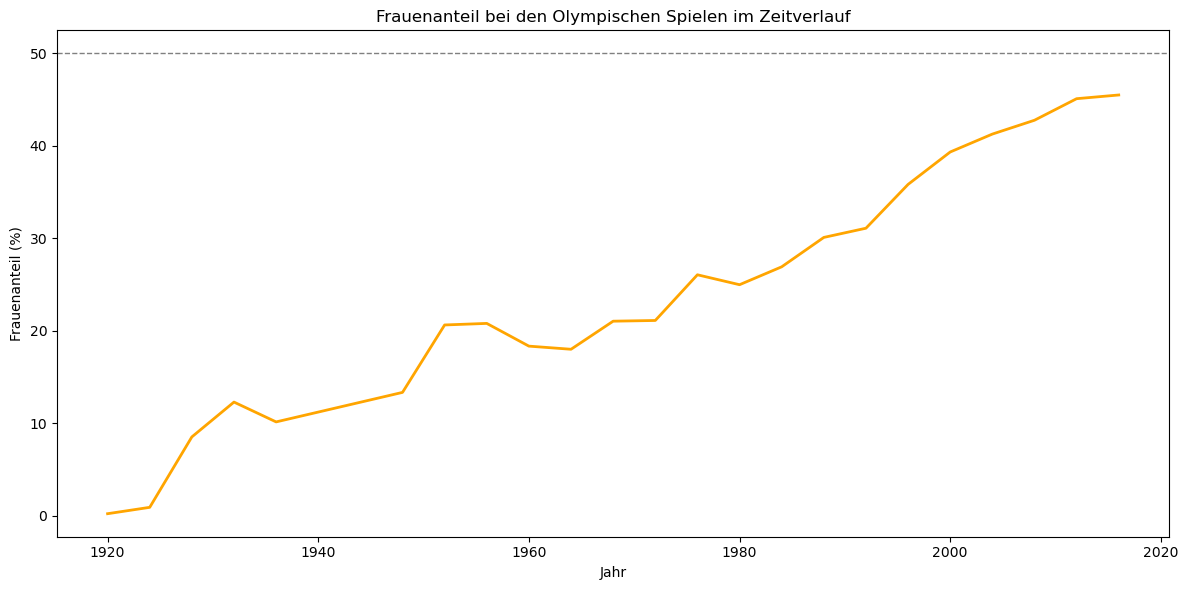

In [15]:
# Frauenanteil pro Jahr berechnen
gender_trend = df.groupby(['year', 'sex']).size().unstack()
gender_trend['frauenanteil'] = gender_trend['F'] / (gender_trend['F'] + gender_trend['M']) * 100
plt.figure(figsize=(12, 6))
plt.plot(gender_trend.index, gender_trend['frauenanteil'], color='orange', linewidth=2)
plt.axhline(y=50, color='gray', linestyle='--', linewidth=1)
plt.title('Frauenanteil bei den Olympischen Spielen im Zeitverlauf')
plt.xlabel('Jahr')
plt.ylabel('Frauenanteil (%)')
plt.tight_layout()
plt.show()

## Frauenanteil pro Land bei den aktuellsten Olympischen Spielen

Eine Weltkarte zeigt den **Frauenanteil je Nation** bei den zuletzt ausgetragenen Olympischen Spielen. Länder mit weniger als 2 Athleten werden grau dargestellt. Im Mouseover sind NOC-Code, Frauenanteil sowie die Gesamtzahl der Athleten und der Frauenanteil absolut einsehbar.

In [16]:
import plotly.graph_objects as go
import numpy as np

latest_year = df['year'].max()

noc_to_iso3 = {
    'AFG': 'AFG', 'ALB': 'ALB', 'ALG': 'DZA', 'AND': 'AND', 'ANG': 'AGO',
    'ANT': 'ATG', 'ARG': 'ARG', 'ARM': 'ARM', 'ARU': 'ABW', 'ASA': 'ASM',
    'AUS': 'AUS', 'AUT': 'AUT', 'AZE': 'AZE', 'BAH': 'BHS', 'BAN': 'BGD',
    'BAR': 'BRB', 'BDI': 'BDI', 'BEL': 'BEL', 'BEN': 'BEN', 'BER': 'BMU',
    'BHU': 'BTN', 'BIH': 'BIH', 'BIZ': 'BLZ', 'BLR': 'BLR', 'BOL': 'BOL',
    'BOT': 'BWA', 'BRA': 'BRA', 'BRN': 'BRN', 'BUL': 'BGR', 'BUR': 'BFA',
    'CAF': 'CAF', 'CAM': 'KHM', 'CAN': 'CAN', 'CAY': 'CYM', 'CGO': 'COG',
    'CHA': 'TCD', 'CHI': 'CHL', 'CHN': 'CHN', 'CIV': 'CIV', 'CMR': 'CMR',
    'COD': 'COD', 'COK': 'COK', 'COL': 'COL', 'COM': 'COM', 'CPV': 'CPV',
    'CRC': 'CRI', 'CRO': 'HRV', 'CUB': 'CUB', 'CYP': 'CYP', 'CZE': 'CZE',
    'DEN': 'DNK', 'DJI': 'DJI', 'DMA': 'DMA', 'DOM': 'DOM', 'ECU': 'ECU',
    'EGY': 'EGY', 'ERI': 'ERI', 'ESA': 'SLV', 'ESP': 'ESP', 'EST': 'EST',
    'ETH': 'ETH', 'FIJ': 'FJI', 'FIN': 'FIN', 'FRA': 'FRA', 'FSM': 'FSM',
    'GAB': 'GAB', 'GAM': 'GMB', 'GBR': 'GBR', 'GBS': 'GNB', 'GEO': 'GEO',
    'GEQ': 'GNQ', 'GER': 'DEU', 'GHA': 'GHA', 'GRE': 'GRC', 'GRN': 'GRD',
    'GUA': 'GTM', 'GUI': 'GIN', 'GUM': 'GUM', 'GUY': 'GUY', 'HAI': 'HTI',
    'HON': 'HND', 'HUN': 'HUN', 'INA': 'IDN', 'IND': 'IND', 'IRI': 'IRN',
    'IRL': 'IRL', 'IRQ': 'IRQ', 'ISL': 'ISL', 'ISR': 'ISR', 'ISV': 'VIR',
    'ITA': 'ITA', 'IVB': 'VGB', 'JAM': 'JAM', 'JOR': 'JOR', 'JPN': 'JPN',
    'KAZ': 'KAZ', 'KEN': 'KEN', 'KGZ': 'KGZ', 'KIR': 'KIR', 'KOR': 'KOR',
    'KOS': 'XKX', 'KSA': 'SAU', 'KUW': 'KWT', 'LAO': 'LAO', 'LAT': 'LVA',
    'LBA': 'LBY', 'LBR': 'LBR', 'LCA': 'LCA', 'LES': 'LSO', 'LIB': 'LBN',
    'LIE': 'LIE', 'LTU': 'LTU', 'LUX': 'LUX', 'MAD': 'MDG', 'MAR': 'MAR',
    'MAS': 'MYS', 'MAW': 'MWI', 'MDA': 'MDA', 'MDV': 'MDV', 'MEX': 'MEX',
    'MGL': 'MNG', 'MKD': 'MKD', 'MLI': 'MLI', 'MLT': 'MLT', 'MNE': 'MNE',
    'MON': 'MCO', 'MOZ': 'MOZ', 'MRI': 'MUS', 'MTN': 'MRT', 'MYA': 'MMR',
    'NAM': 'NAM', 'NCA': 'NIC', 'NED': 'NLD', 'NEP': 'NPL', 'NGR': 'NGA',
    'NIG': 'NER', 'NOR': 'NOR', 'NRU': 'NRU', 'NZL': 'NZL', 'OMA': 'OMN',
    'PAK': 'PAK', 'PAN': 'PAN', 'PAR': 'PRY', 'PER': 'PER', 'PHI': 'PHL',
    'PLE': 'PSE', 'PLW': 'PLW', 'PNG': 'PNG', 'POL': 'POL', 'POR': 'PRT',
    'PRK': 'PRK', 'PUR': 'PRI', 'QAT': 'QAT', 'ROU': 'ROU', 'RSA': 'ZAF',
    'RUS': 'RUS', 'RWA': 'RWA', 'SAM': 'WSM', 'SEN': 'SEN', 'SEY': 'SYC',
    'SGP': 'SGP', 'SKN': 'KNA', 'SLE': 'SLE', 'SLO': 'SVN', 'SMR': 'SMR',
    'SOL': 'SLB', 'SOM': 'SOM', 'SRB': 'SRB', 'SRI': 'LKA', 'SSD': 'SSD',
    'STP': 'STP', 'SUD': 'SDN', 'SUI': 'CHE', 'SUR': 'SUR', 'SVK': 'SVK',
    'SWE': 'SWE', 'SWZ': 'SWZ', 'SYR': 'SYR', 'TAN': 'TZA', 'TGA': 'TON',
    'THA': 'THA', 'TJK': 'TJK', 'TKM': 'TKM', 'TLS': 'TLS', 'TOG': 'TGO',
    'TPE': 'TWN', 'TRI': 'TTO', 'TUN': 'TUN', 'TUR': 'TUR', 'TUV': 'TUV',
    'UAE': 'ARE', 'UGA': 'UGA', 'UKR': 'UKR', 'URU': 'URY', 'USA': 'USA',
    'UZB': 'UZB', 'VAN': 'VUT', 'VEN': 'VEN', 'VIE': 'VNM', 'VIN': 'VCT',
    'YEM': 'YEM', 'ZAM': 'ZMB', 'ZIM': 'ZWE',
}

gender_country = df[df['year'] == latest_year].groupby(['noc', 'sex']).size().unstack(fill_value=0)
gender_country['frauenanteil'] = gender_country['F'] / (gender_country['F'] + gender_country['M']) * 100
gender_country = gender_country.reset_index()
gender_country['iso3'] = gender_country['noc'].map(noc_to_iso3)
gender_country = gender_country.dropna(subset=['iso3'])
gender_country['n'] = (gender_country['F'] + gender_country['M']).astype(int)
gender_country.loc[gender_country['n'] < 2, 'frauenanteil'] = None

cd = np.stack([
    gender_country['noc'].values,
    gender_country['frauenanteil'].round(1).astype(str).values,
    gender_country['n'].astype(str).values,
    gender_country['F'].astype(int).astype(str).values,
], axis=-1)

fig = go.Figure(go.Choropleth(
    locations=gender_country['iso3'],
    z=gender_country['frauenanteil'],
    customdata=cd,
    hovertemplate=(
        '<b>%{customdata[0]}</b><br>'
        'Frauenanteil: %{customdata[1]}%<br>'
        'Athleten gesamt: %{customdata[2]}<br>'
        'davon Frauen: %{customdata[3]}'
        '<extra></extra>'
    ),
    colorscale=['#cc0000', '#ffff00', '#00cc44'],
    zmin=0,
    zmax=70,
    colorbar=dict(
        title=dict(text='Frauenanteil (%)', font=dict(color='white')),
        tickfont=dict(color='white')
    )
))

fig.update_layout(
    title=f'Frauenanteil pro Land – Olympische Spiele {latest_year} (mind. 2 Athleten)',
    autosize=True,
    height=900,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular',
        bgcolor='#111111',
        coastlinecolor='#333333',
        showocean=True,
        oceancolor='#111111',
        lonaxis=dict(range=[-180, 180]),
        lataxis=dict(range=[-60, 85]),
        landcolor='#555555',
    ),
    paper_bgcolor='#111111',
    font_color='white',
    title_font_size=14,
    margin=dict(l=0, r=0, t=40, b=0),
)

fig.show(config={'responsive': True})

## Olympia-Teilnahme im Verhältnis zur Bevölkerung

Wie stark ist ein Kontinent gemessen an seiner Bevölkerungsgröße bei Olympia vertreten? Die Anzahl der Athleten pro Kontinent wird mit Bevölkerungsdaten der Weltbank normalisiert und als **Athleten pro Million Einwohner** im Zeitverlauf dargestellt.

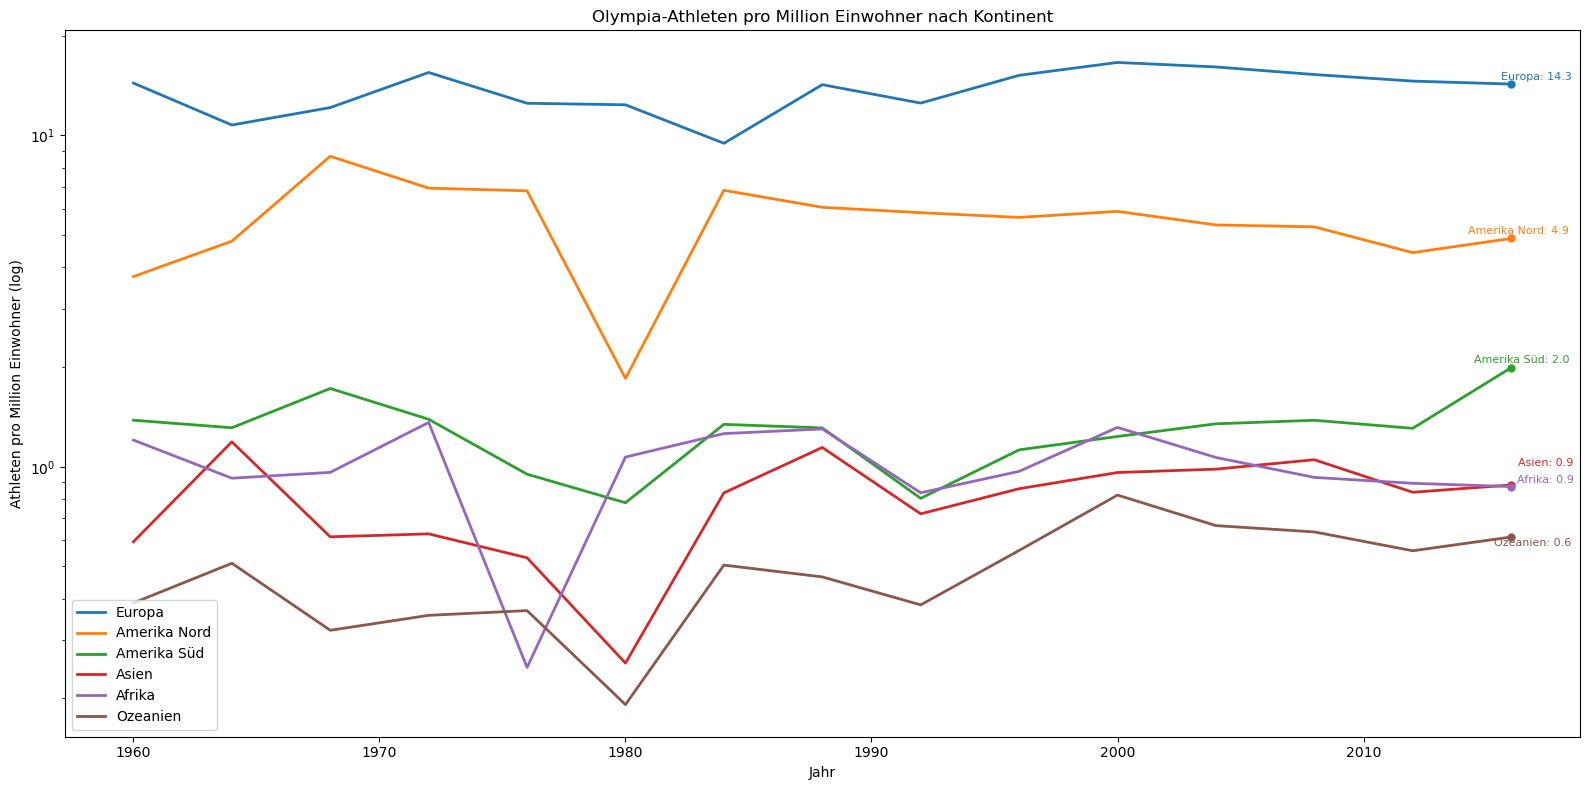

In [17]:
from adjustText import adjust_text

# ── Block 1: Kontinent-Mapping ────────────────────────────────────────────────
continent_mapping = {
    # Europa
    'AUT': 'Europa', 'BEL': 'Europa', 'DEN': 'Europa', 'FIN': 'Europa',
    'FRA': 'Europa', 'GER': 'Europa', 'GBR': 'Europa', 'GRE': 'Europa',
    'HUN': 'Europa', 'ITA': 'Europa', 'NED': 'Europa', 'NOR': 'Europa',
    'POL': 'Europa', 'POR': 'Europa', 'ROU': 'Europa', 'RUS': 'Europa',
    'ESP': 'Europa', 'SWE': 'Europa', 'SUI': 'Europa', 'TCH': 'Europa',
    'URS': 'Europa', 'YUG': 'Europa', 'CRO': 'Europa', 'CZE': 'Europa',
    'EST': 'Europa', 'LAT': 'Europa', 'LTU': 'Europa', 'SVK': 'Europa',
    'SLO': 'Europa', 'BLR': 'Europa', 'UKR': 'Europa', 'BUL': 'Europa',
    'IRL': 'Europa', 'ISL': 'Europa', 'LUX': 'Europa', 'MDA': 'Europa',
    'ARM': 'Europa', 'AZE': 'Europa', 'GEO': 'Europa', 'KAZ': 'Europa',
    'MKD': 'Europa', 'ALB': 'Europa', 'AND': 'Europa', 'BIH': 'Europa',
    'CYP': 'Europa', 'FRG': 'Europa', 'GDR': 'Europa', 'ISR': 'Europa',
    'LIE': 'Europa', 'MLT': 'Europa', 'MON': 'Europa', 'MNE': 'Europa',
    'SCG': 'Europa', 'SRB': 'Europa', 'SMR': 'Europa',
    # Amerika Nord
    'USA': 'Amerika Nord', 'CAN': 'Amerika Nord', 'MEX': 'Amerika Nord',
    'CUB': 'Amerika Nord', 'JAM': 'Amerika Nord', 'TTO': 'Amerika Nord',
    'BAH': 'Amerika Nord', 'DOM': 'Amerika Nord', 'HAI': 'Amerika Nord',
    'PUR': 'Amerika Nord', 'ANT': 'Amerika Nord', 'BAR': 'Amerika Nord',
    'BIZ': 'Amerika Nord', 'CAY': 'Amerika Nord', 'GRN': 'Amerika Nord',
    'IVB': 'Amerika Nord', 'SKN': 'Amerika Nord', 'LCA': 'Amerika Nord',
    'VIN': 'Amerika Nord', 'TCA': 'Amerika Nord', 'CRC': 'Amerika Nord',
    'ESA': 'Amerika Nord', 'GUA': 'Amerika Nord', 'HON': 'Amerika Nord',
    'NCA': 'Amerika Nord', 'PAN': 'Amerika Nord',
    # Amerika Süd
    'BRA': 'Amerika Süd', 'ARG': 'Amerika Süd', 'CHI': 'Amerika Süd',
    'COL': 'Amerika Süd', 'VEN': 'Amerika Süd', 'ECU': 'Amerika Süd',
    'PER': 'Amerika Süd', 'URU': 'Amerika Süd', 'GUY': 'Amerika Süd',
    'BOL': 'Amerika Süd', 'PAR': 'Amerika Süd', 'SUR': 'Amerika Süd',
    # Asien
    'CHN': 'Asien', 'JPN': 'Asien', 'KOR': 'Asien', 'IND': 'Asien',
    'IRI': 'Asien', 'IRQ': 'Asien', 'PRK': 'Asien', 'MGL': 'Asien',
    'PAK': 'Asien', 'PHI': 'Asien', 'THA': 'Asien', 'VIE': 'Asien',
    'MAS': 'Asien', 'SGP': 'Asien', 'INA': 'Asien', 'HKG': 'Asien',
    'TPE': 'Asien', 'BRN': 'Asien', 'KUW': 'Asien', 'LBN': 'Asien',
    'QAT': 'Asien', 'KSA': 'Asien', 'SYR': 'Asien', 'UZB': 'Asien',
    'TJK': 'Asien', 'TKM': 'Asien', 'KGZ': 'Asien', 'AFG': 'Asien',
    'BAN': 'Asien', 'CAM': 'Asien', 'MDV': 'Asien', 'NEP': 'Asien',
    'SRI': 'Asien', 'UAE': 'Asien', 'YEM': 'Asien', 'BHR': 'Asien',
    'JOR': 'Asien', 'OMA': 'Asien', 'MYA': 'Asien', 'LAO': 'Asien',
    # Afrika
    'ETH': 'Afrika', 'KEN': 'Afrika', 'NGR': 'Afrika', 'RSA': 'Afrika',
    'EGY': 'Afrika', 'MAR': 'Afrika', 'ALG': 'Afrika', 'TUN': 'Afrika',
    'CMR': 'Afrika', 'GHA': 'Afrika', 'ZIM': 'Afrika', 'UGA': 'Afrika',
    'TAN': 'Afrika', 'SEN': 'Afrika', 'CIV': 'Afrika', 'MOZ': 'Afrika',
    'NAM': 'Afrika', 'BOT': 'Afrika', 'BUR': 'Afrika', 'CAF': 'Afrika',
    'CGO': 'Afrika', 'DJI': 'Afrika', 'ERI': 'Afrika', 'GAB': 'Afrika',
    'GMB': 'Afrika', 'GEQ': 'Afrika', 'GUI': 'Afrika', 'GBS': 'Afrika',
    'LBA': 'Afrika', 'LES': 'Afrika', 'LBR': 'Afrika', 'MDG': 'Afrika',
    'MLI': 'Afrika', 'MTN': 'Afrika', 'MRI': 'Afrika', 'NIG': 'Afrika',
    'RWA': 'Afrika', 'STP': 'Afrika', 'SEY': 'Afrika', 'SLE': 'Afrika',
    'SOM': 'Afrika', 'SUD': 'Afrika', 'SWZ': 'Afrika', 'TOG': 'Afrika',
    'ZAM': 'Afrika', 'ZAN': 'Afrika', 'BEN': 'Afrika', 'CPV': 'Afrika',
    'COM': 'Afrika',
    # Ozeanien
    'AUS': 'Ozeanien', 'NZL': 'Ozeanien', 'FIJ': 'Ozeanien', 'PNG': 'Ozeanien',
    'SAM': 'Ozeanien', 'SOL': 'Ozeanien', 'TON': 'Ozeanien', 'VAN': 'Ozeanien',
    'FSM': 'Ozeanien', 'KIR': 'Ozeanien', 'NRU': 'Ozeanien', 'PLW': 'Ozeanien',
}

df['kontinent'] = df['noc'].map(continent_mapping)

# ── Block 2: Bevölkerungsdaten via Weltbank-API ───────────────────────────────
import requests
import os

POP_CACHE = '../data/population_cache.csv'

regions = {
    'EUU': 'Europa',
    'NAC': 'Amerika Nord',
    'LCN': 'Amerika Süd',
    'EAS': 'Asien',
    'SSF': 'Afrika',
    'OED': 'Ozeanien',
}

if os.path.exists(POP_CACHE):
    df_pop = pd.read_csv(POP_CACHE)
else:
    pop_data = []
    for code, name in regions.items():
        r = requests.get(
            f"https://api.worldbank.org/v2/country/{code}/indicator/SP.POP.TOTL"
            f"?format=json&per_page=1000&date=1896:2016"
        )
        r.raise_for_status()
        for entry in r.json()[1]:
            if entry['value']:
                pop_data.append({
                    'kontinent': name,
                    'year': int(entry['date']),
                    'population': entry['value']
                })
    df_pop = pd.DataFrame(pop_data).dropna()
    df_pop.to_csv(POP_CACHE, index=False)

# ── Block 3: Visualisierung ───────────────────────────────────────────────────
athletes_per_continent = df.groupby(['year', 'kontinent']).size().reset_index(name='athleten')
df_merged = athletes_per_continent.merge(df_pop, on=['year', 'kontinent'])
df_merged['athleten_pro_million'] = df_merged['athleten'] / (df_merged['population'] / 1_000_000)

last_year = df_merged['year'].max()
order = (df_merged[df_merged['year'] == last_year]
         .sort_values('athleten_pro_million', ascending=False)['kontinent']
         .tolist())

fig, ax = plt.subplots(figsize=(16, 8))
texts = []

for kontinent in order:
    data = df_merged[df_merged['kontinent'] == kontinent].sort_values('year')
    line, = ax.plot(data['year'], data['athleten_pro_million'], label=kontinent, linewidth=2)
    last = data.iloc[-1]
    ax.plot(last['year'], last['athleten_pro_million'], 'o', markersize=5, color=line.get_color())
    texts.append(ax.text(
        last['year'] + 0.5, last['athleten_pro_million'],
        f"{kontinent}: {last['athleten_pro_million']:.1f}",
        fontsize=8, color=line.get_color()
    ))

ax.set_yscale('log')
ax.set_title('Olympia-Athleten pro Million Einwohner nach Kontinent')
ax.set_xlabel('Jahr')
ax.set_ylabel('Athleten pro Million Einwohner (log)')

handles, labels = ax.get_legend_handles_labels()
order_idx = [labels.index(k) for k in order if k in labels]
ax.legend([handles[i] for i in order_idx], [labels[i] for i in order_idx], loc='lower left')

adjust_text(texts, ax=ax, only_move={'points': 'y', 'texts': 'y'},
            avoid_points=True, avoid_self=True)
plt.tight_layout()
plt.show()


## Performance Score nach Kontinent

Um die **Effizienz** der Athleten je Kontinent zu vergleichen, wird ein gewichteter Performance Score berechnet: Gold zählt 3, Silber 2, Bronze 1 Punkt. Der Score wird auf 100 Athleten normalisiert und ab 1945 im Zeitverlauf dargestellt – ab diesem Jahr sind die Teilnehmerfelder groß und stabil genug für einen aussagekräftigen Vergleich.

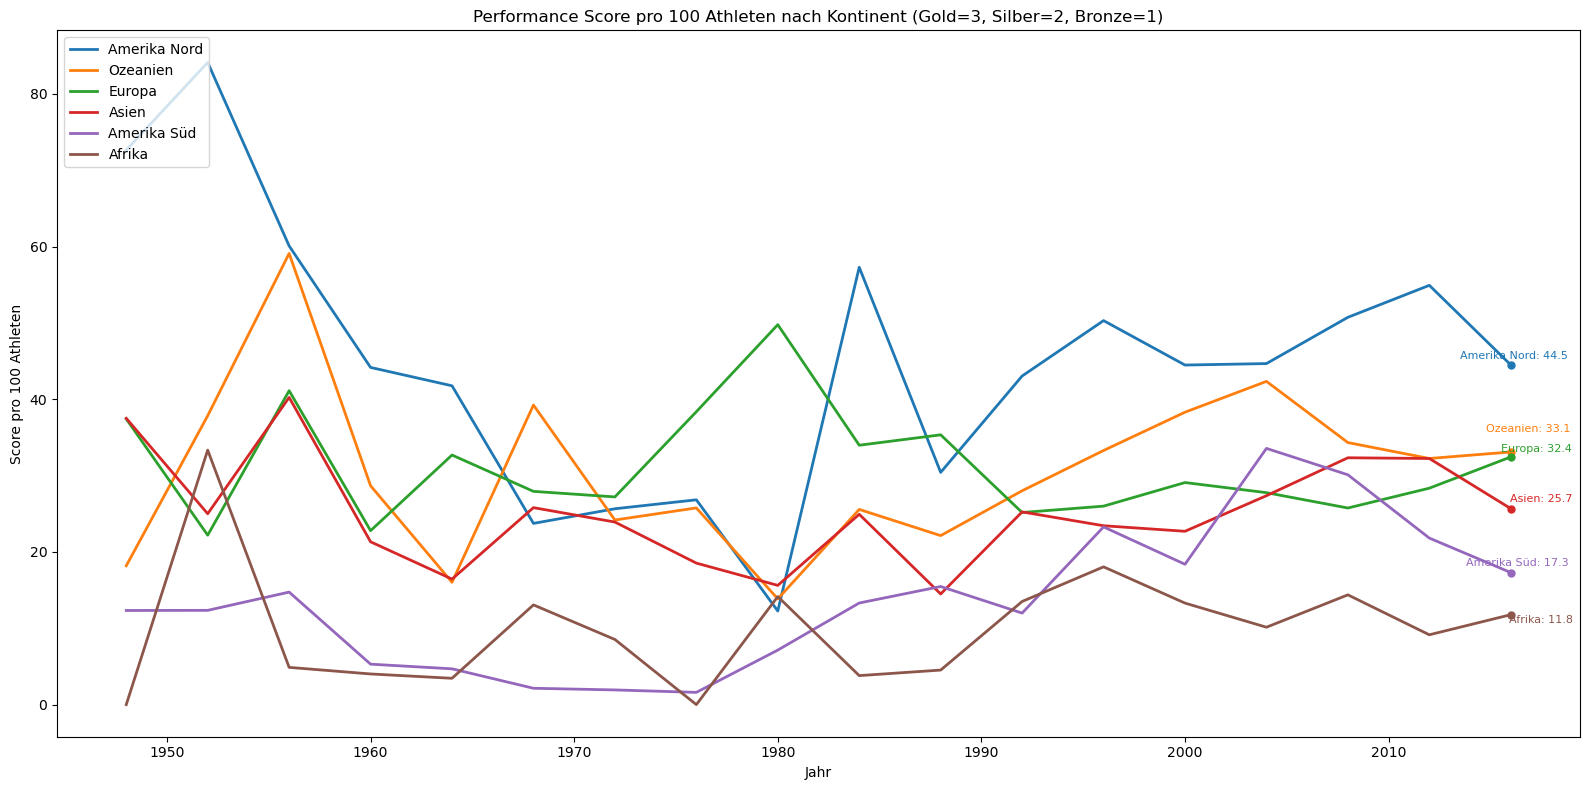

In [18]:
from adjustText import adjust_text

# Performance Score
medal_points = {'Gold': 3, 'Silver': 2, 'Bronze': 1}
df['punkte'] = df['medal'].map(medal_points).fillna(0)

score_per_continent = df.groupby(['year', 'kontinent'])['punkte'].sum().reset_index(name='score')
athletes_per_continent = df.groupby(['year', 'kontinent']).size().reset_index(name='athleten')

df_score = score_per_continent.merge(athletes_per_continent, on=['year', 'kontinent'])
df_score = df_score[df_score['year'] >= 1945]
df_score['score_pro_100'] = df_score['score'] / df_score['athleten'] * 100

last_year = df_score['year'].max()
order_score = df_score[df_score['year'] == last_year].sort_values('score_pro_100', ascending=False)['kontinent'].tolist()

fig, ax = plt.subplots(figsize=(16, 8))

texts = []
for kontinent in order_score:
    data = df_score[df_score['kontinent'] == kontinent].sort_values('year')
    line, = ax.plot(data['year'], data['score_pro_100'], label=kontinent, linewidth=2)
    last = data.iloc[-1]
    ax.plot(last['year'], last['score_pro_100'], 'o', markersize=5, color=line.get_color())
    texts.append(ax.text(last['year'] + 0.5, last['score_pro_100'],
                         f"{kontinent}: {last['score_pro_100']:.1f}",
                         fontsize=8, color=line.get_color()))

ax.set_title('Performance Score pro 100 Athleten nach Kontinent (Gold=3, Silber=2, Bronze=1)')
ax.set_xlabel('Jahr')
ax.set_ylabel('Score pro 100 Athleten')

handles, labels = ax.get_legend_handles_labels()
order_idx = [labels.index(k) for k in order_score if k in labels]
ax.legend([handles[i] for i in order_idx], [labels[i] for i in order_idx], loc='upper left')

adjust_text(texts, ax=ax, only_move={'points': 'y', 'texts': 'y'},
            avoid_points=True, avoid_self=True)

plt.tight_layout()
plt.show()


## Heimvorteil bei Olympia

Profitieren Gastgeberländer von einem **Heimvorteil**? Für jedes Ausrichterland wird der gewichtete Performance Score in drei Zeitpunkten verglichen: bei der **vorherigen Olympiade**, **als Gastgeber** und bei der **nächsten Olympiade**. So lässt sich ablesen, ob die Ausrichtung der Spiele einen messbaren Einfluss auf die sportliche Leistung hat.

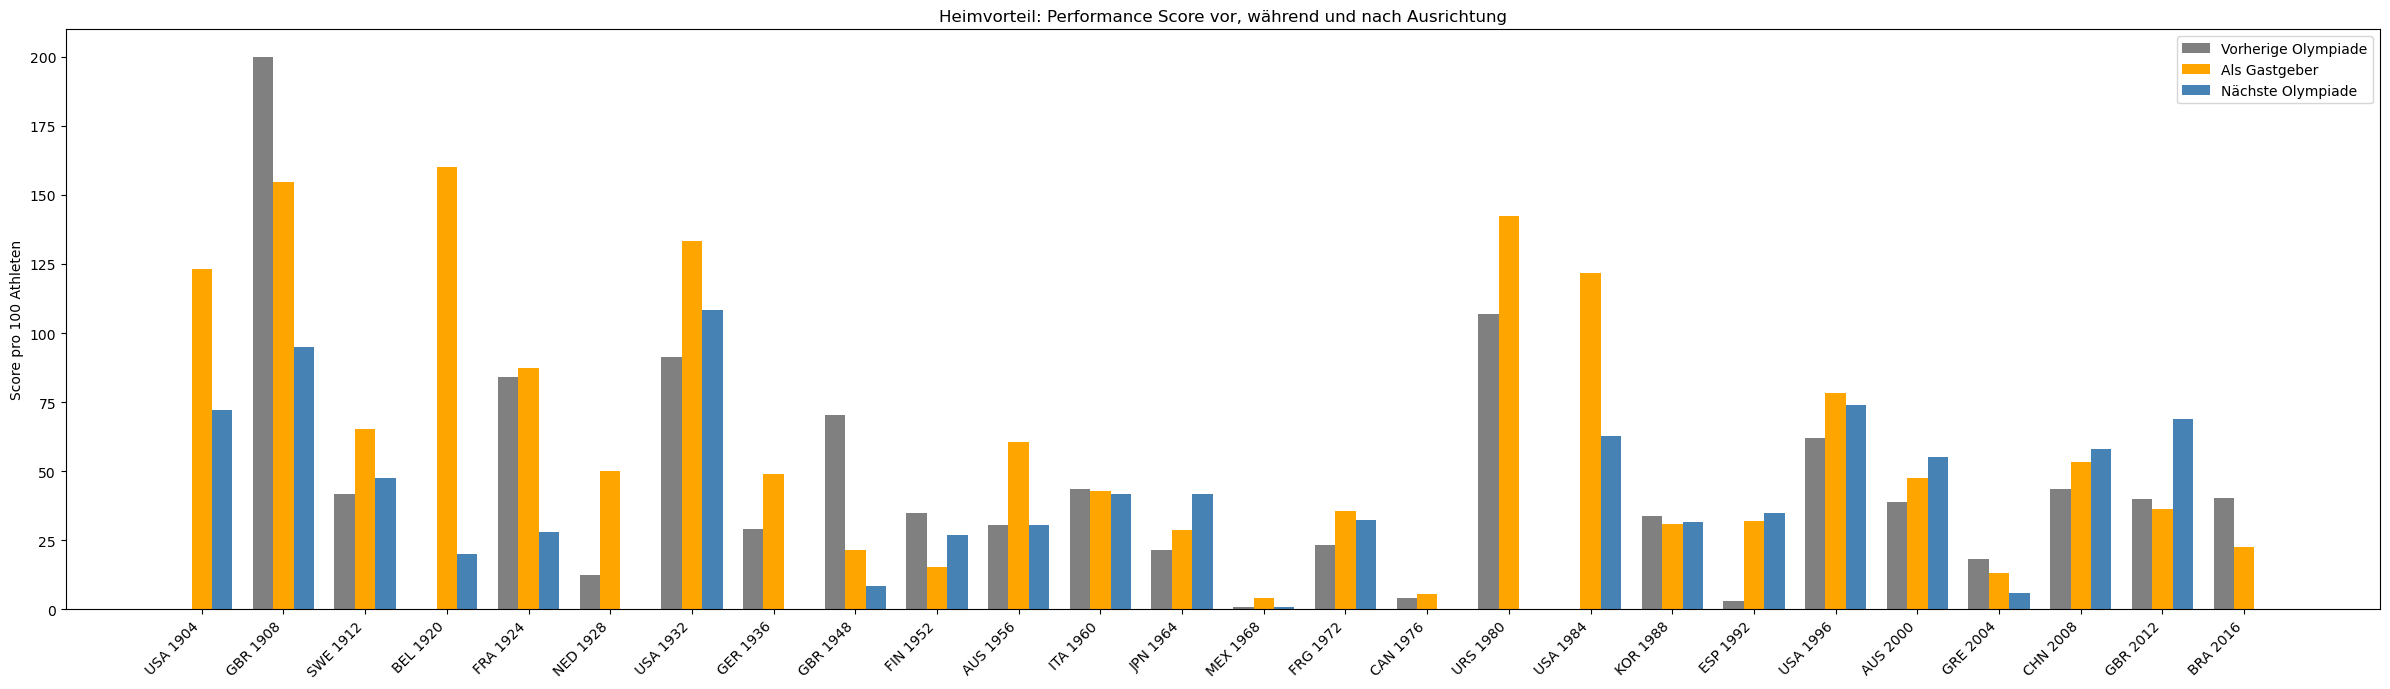

In [19]:
host_countries = {
    1896: 'GRE', 1900: 'FRA', 1904: 'USA', 1908: 'GBR',
    1912: 'SWE', 1920: 'BEL', 1924: 'FRA', 1928: 'NED', 1932: 'USA',
    1936: 'GER', 1948: 'GBR', 1952: 'FIN', 1956: 'AUS', 1960: 'ITA',
    1964: 'JPN', 1968: 'MEX', 1972: 'FRG', 1976: 'CAN', 1980: 'URS',
    1984: 'USA', 1988: 'KOR', 1992: 'ESP', 1996: 'USA', 2000: 'AUS',
    2004: 'GRE', 2008: 'CHN', 2012: 'GBR', 2016: 'BRA'
}

# df_home berechnen
score_home = df.groupby(['year', 'noc'])['punkte'].sum().reset_index(name='score')
athletes_home = df.groupby(['year', 'noc']).size().reset_index(name='athleten')
df_home = score_home.merge(athletes_home, on=['year', 'noc'])
df_home['score_pro_100'] = df_home['score'] / df_home['athleten'] * 100

results = []
years_sorted = sorted(host_countries.keys())

for year, noc in host_countries.items():
    idx = years_sorted.index(year)

    prev_year = years_sorted[idx - 1] if idx > 0 else None
    next_year = years_sorted[idx + 1] if idx < len(years_sorted) - 1 else None

    for label, y in [('Vorherige Olympiade', prev_year), ('Als Gastgeber', year), ('Nächste Olympiade', next_year)]:
        if y is None:
            continue
        row = df_home[(df_home['noc'] == noc) & (df_home['year'] == y)]
        if len(row) > 0:
            results.append({
                'land': f"{noc} {year}",
                'zeitpunkt': label,
                'score_pro_100': row['score_pro_100'].values[0]
            })

df_heimvorteil = pd.DataFrame(results)

lands = df_heimvorteil['land'].unique()
x = range(len(lands))
width = 0.25
colors = {'Vorherige Olympiade': 'gray', 'Als Gastgeber': 'orange', 'Nächste Olympiade': 'steelblue'}

plt.figure(figsize=(24, 7))
for i, (label, color) in enumerate(colors.items()):
    vals = [df_heimvorteil[(df_heimvorteil['land'] == l) & (df_heimvorteil['zeitpunkt'] == label)]['score_pro_100'].values
            for l in lands]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    plt.bar([xi + i * width for xi in x], vals, width=width, label=label, color=color)

plt.xticks([xi + width for xi in x], lands, rotation=45, ha='right')
plt.title('Heimvorteil: Performance Score vor, während und nach Ausrichtung')
plt.ylabel('Score pro 100 Athleten')
plt.legend()
plt.tight_layout()
plt.show()
